# Importance Sampling

Exact value of the integral = 0.3862943611

Monte Carlo results using the transformed variable x = -1 + sqrt(1 + 3u):
N =    100 | estimate = 0.3961119058 | absolute error = 0.0098175447
N =   1000 | estimate = 0.3876298944 | absolute error = 0.0013355333
N =  10000 | estimate = 0.3870292883 | absolute error = 0.0007349272
N = 100000 | estimate = 0.3862042507 | absolute error = 0.0000901104


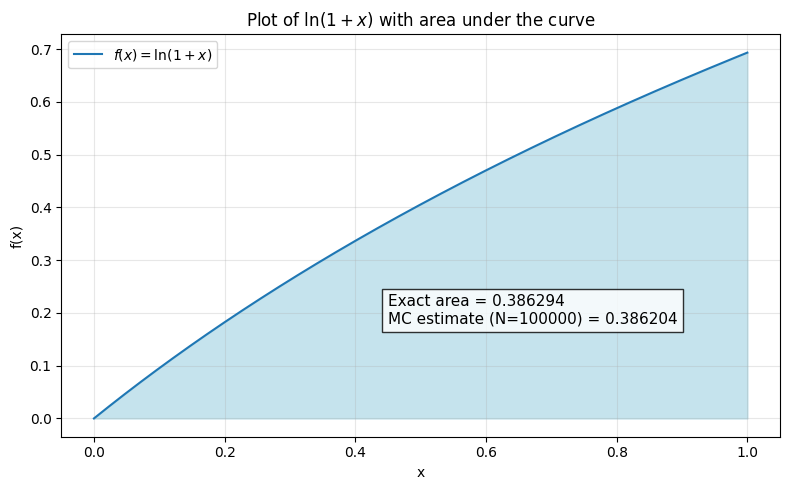

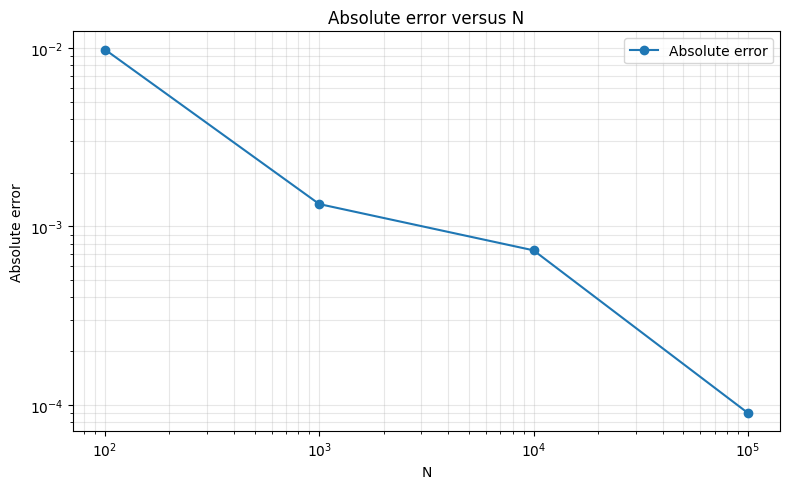

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Define the random seed used to make the simulation reproducible.
SEED = 1

# Define the sample sizes requested in the exercise.
N_VALUES = np.array([10**2, 10**3, 10**4, 10**5], dtype=int)

# Define the number of points used to draw the continuous curve of the integrand.
PLOT_POINTS = 1000


def exact_integral() -> float:
    """Return the exact value of the integral int_0^1 ln(1 + x) dx.

    Returns:
        Exact analytical value of the integral.
    """
    # Compute the closed-form expression 2 * ln(2) - 1.
    return 2.0 * np.log(2.0) - 1.0


def f(x: np.ndarray) -> np.ndarray:
    """Evaluate the target integrand f(x) = ln(1 + x).

    Args:
        x: Points where the integrand will be evaluated.

    Returns:
        Value of ln(1 + x) at the input points.
    """
    # Use log1p for better numerical stability.
    return np.log1p(x)


def g(x: np.ndarray) -> np.ndarray:
    """Evaluate the chosen proposal PDF g(x) = (2/3) * (1 + x) on [0, 1].

    Args:
        x: Points where the proposal PDF will be evaluated.

    Returns:
        Value of the proposal PDF at the input points.
    """
    # Evaluate the proposal density.
    return (2.0 / 3.0) * (1.0 + x)


def inverse_cdf_g(u: np.ndarray) -> np.ndarray:
    """Generate samples from g(x) using inverse transform sampling.

    The proposal CDF is:
        G(x) = (x^2 + 2x) / 3

    Solving U = G(x) for x gives:
        x = -1 + sqrt(1 + 3U)

    Args:
        u: Uniform random samples in [0, 1].

    Returns:
        Samples distributed according to g(x).
    """
    # Apply the inverse CDF derived analytically.
    return -1.0 + np.sqrt(1.0 + 3.0 * u)


def importance_sampling_estimate(n: int, seed: int) -> float:
    """Estimate the integral using importance sampling for one sample size.

    Args:
        n: Number of Monte Carlo samples.
        seed: Seed used by the random number generator.

    Returns:
        Importance sampling estimate of the integral.
    """
    # Create a reproducible random number generator for this experiment.
    rng = np.random.default_rng(seed)

    # Generate uniform random numbers in the interval [0, 1].
    u = rng.uniform(0.0, 1.0, n)

    # Transform the uniform samples into samples distributed according to g(x).
    x = inverse_cdf_g(u)

    # Evaluate the target function at the generated samples.
    fx = f(x)

    # Evaluate the proposal PDF at the generated samples.
    gx = g(x)

    # Compute the importance sampling weights f(x) / g(x).
    weights = fx / gx
    # Esses weights são as amostras da variável aleatória cujo valor esperado é a integral

    # Return the Monte Carlo mean of the weighted samples.
    # Pela Lei dos Grandes Números, conforme n cresce, essa média converge para I = E_g[f(X)/g(X)] = int f(x) dx.
    return np.mean(weights)


def main() -> None:
    """Run the full analytical comparison and Monte Carlo simulation."""
    # Compute the exact value of the integral.
    exact_value = exact_integral()

    # Print the exact analytical result before running the simulation.
    print(f"Exact value of the integral = {exact_value:.10f}")
    print()

    # Create empty Python lists to store the Monte Carlo estimates.
    estimates = []

    # Create empty Python lists to store the absolute errors.
    absolute_errors = []

    # Print a header for the numerical results.
    print("Monte Carlo results using the transformed variable x = -1 + sqrt(1 + 3u):")

    # Loop over all requested sample sizes.
    for n in N_VALUES:
        # Compute the estimate for the current sample size.
        estimate = importance_sampling_estimate(n=n, seed=SEED + int(n))

        # Compute the absolute error relative to the exact value.
        error = abs(estimate - exact_value)

        # Store the estimate for later plotting and analysis.
        estimates.append(estimate)

        # Store the absolute error for later plotting.
        absolute_errors.append(error)

        # Print the current sample size, estimate, and error.
        print(f"N = {n:6d} | estimate = {estimate:.10f} | absolute error = {error:.10f}")

    # Convert the list of estimates into a NumPy array.
    estimates = np.array(estimates)

    # Convert the list of absolute errors into a NumPy array.
    absolute_errors = np.array(absolute_errors)

    # Create x values for the continuous plot of the target function.
    x_plot = np.linspace(0.0, 1.0, PLOT_POINTS)

    # Evaluate the target function on the plotting grid.
    y_plot = f(x_plot)

    # Create a new figure for the area plot.
    plt.figure(figsize=(8, 5))

    # Plot the target function.
    plt.plot(x_plot, y_plot, label=r"$f(x)=\ln(1+x)$")

    # Fill the area under the target function.
    plt.fill_between(x_plot, y_plot, color="lightblue", alpha=0.7)

    # Add a text label with the exact area and the largest-N estimate.
    plt.text(
        0.45,
        0.18,
        f"Exact area = {exact_value:.6f}\nMC estimate (N={N_VALUES[-1]}) = {estimates[-1]:.6f}",
        fontsize=11,
        bbox=dict(facecolor="white", alpha=0.8),
    )

    # Label the horizontal axis.
    plt.xlabel("x")

    # Label the vertical axis.
    plt.ylabel("f(x)")

    # Add a title to the area plot.
    plt.title(r"Plot of $\ln(1+x)$ with area under the curve")

    # Add a grid to improve readability.
    plt.grid(True, alpha=0.3)

    # Add the legend.
    plt.legend()

    # Adjust the layout to avoid clipping.
    plt.tight_layout()

    # Create a new figure for the absolute error plot.
    plt.figure(figsize=(8, 5))

    # Plot the absolute error as a function of N on log-log axes.
    plt.loglog(N_VALUES, absolute_errors, marker="o", label="Absolute error")

    # Label the horizontal axis.
    plt.xlabel("N")

    # Label the vertical axis.
    plt.ylabel("Absolute error")

    # Add a title to the error plot.
    plt.title("Absolute error versus N")

    # Add a grid to improve readability.
    plt.grid(True, which="both", alpha=0.3)

    # Add the legend.
    plt.legend()

    # Adjust the layout to avoid clipping.
    plt.tight_layout()

    # Show all generated figures.
    plt.show()


main()

# No Importance Sampling

Exact value of the integral = 0.3862943611

Simple Monte Carlo estimator:
If U ~ Uniform(0, 1), then I = E[ln(1 + U)].
Therefore, x = u and I_hat = (1/N) * sum(ln(1 + x_i)).

Simple Monte Carlo results using x ~ Uniform(0, 1):
N =    100 | estimate = 0.4028810158 | absolute error = 0.0165866547
N =   1000 | estimate = 0.3854835140 | absolute error = 0.0008108472
N =  10000 | estimate = 0.3876435815 | absolute error = 0.0013492204
N = 100000 | estimate = 0.3861806749 | absolute error = 0.0001136862


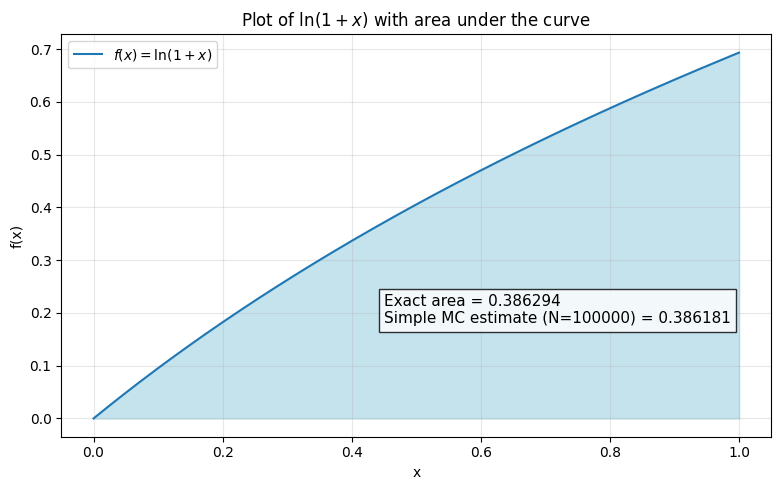

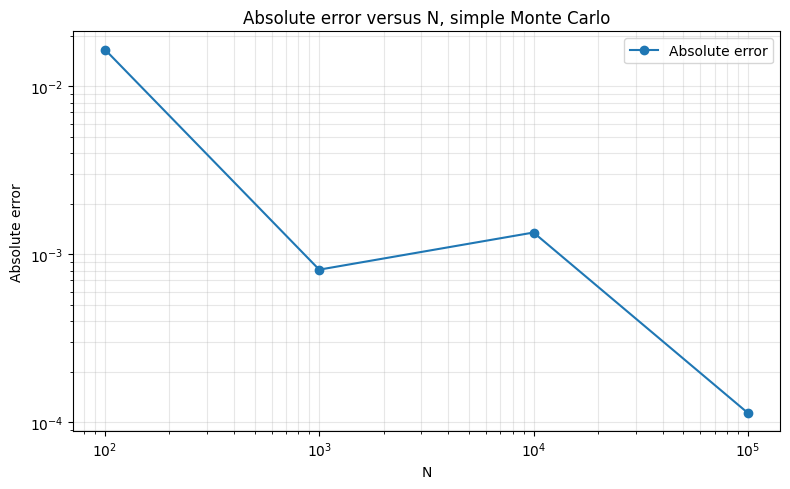

In [2]:
import numpy as np
import matplotlib.pyplot as plt


# Define the random seed used to make the simulation reproducible.
SEED = 1

# Define the sample sizes requested in the exercise.
N_VALUES = np.array([10**2, 10**3, 10**4, 10**5], dtype=int)

# Define the number of points used to draw the continuous curve of the integrand.
PLOT_POINTS = 1000


def exact_integral() -> float:
    """Return the exact value of the integral int_0^1 ln(1 + x) dx.

    Returns:
        Exact analytical value of the integral.
    """
    # Compute the closed-form expression of the integral.
    return 2.0 * np.log(2.0) - 1.0


def f(x: np.ndarray) -> np.ndarray:
    """Evaluate the target integrand f(x) = ln(1 + x).

    Args:
        x: Points where the integrand will be evaluated.

    Returns:
        Value of ln(1 + x) at the input points.
    """
    # Use log1p for better numerical stability.
    return np.log1p(x)


def simple_monte_carlo_estimate(n: int, seed: int) -> float:
    """Estimate the integral using standard Monte Carlo with uniform sampling.

    For this problem, if U ~ Uniform(0, 1), then:
        I = E[ln(1 + U)]

    Therefore, the Monte Carlo estimator is:
        I_hat = (1 / N) * sum(ln(1 + U_i))

    Args:
        n: Number of Monte Carlo samples.
        seed: Seed used by the random number generator.

    Returns:
        Standard Monte Carlo estimate of the integral.
    """
    # Create a reproducible random number generator for this experiment.
    rng = np.random.default_rng(seed)

    # Generate n samples uniformly distributed in the interval [0, 1].
    x = rng.uniform(0.0, 1.0, n)

    # Evaluate the integrand at all generated samples.
    fx = f(x)

    # Return the Monte Carlo average.
    return np.mean(fx)


def main() -> None:
    """Run the full analytical comparison and simple Monte Carlo simulation."""
    # Compute the exact value of the integral.
    exact_value = exact_integral()

    # Print the exact analytical result before running the simulation.
    print(f"Exact value of the integral = {exact_value:.10f}")
    print()

    # Explain the estimator being used in this script.
    print("Simple Monte Carlo estimator:")
    print("If U ~ Uniform(0, 1), then I = E[ln(1 + U)].")
    print("Therefore, x = u and I_hat = (1/N) * sum(ln(1 + x_i)).")
    print()

    # Create empty Python lists to store the Monte Carlo estimates.
    estimates = []

    # Create empty Python lists to store the absolute errors.
    absolute_errors = []

    # Print a header for the numerical results.
    print("Simple Monte Carlo results using x ~ Uniform(0, 1):")

    # Loop over all requested sample sizes.
    for n in N_VALUES:
        # Compute the estimate for the current sample size.
        estimate = simple_monte_carlo_estimate(n=n, seed=SEED + int(n))

        # Compute the absolute error relative to the exact value.
        error = abs(estimate - exact_value)

        # Store the estimate for later plotting and analysis.
        estimates.append(estimate)

        # Store the absolute error for later plotting.
        absolute_errors.append(error)

        # Print the current sample size, estimate, and error.
        print(f"N = {n:6d} | estimate = {estimate:.10f} | absolute error = {error:.10f}")

    # Convert the list of estimates into a NumPy array.
    estimates = np.array(estimates)

    # Convert the list of absolute errors into a NumPy array.
    absolute_errors = np.array(absolute_errors)

    # Create x values for the continuous plot of the target function.
    x_plot = np.linspace(0.0, 1.0, PLOT_POINTS)

    # Evaluate the target function on the plotting grid.
    y_plot = f(x_plot)

    # Create a new figure for the area plot.
    plt.figure(figsize=(8, 5))

    # Plot the target function.
    plt.plot(x_plot, y_plot, label=r"$f(x)=\ln(1+x)$")

    # Fill the area under the target function.
    plt.fill_between(x_plot, y_plot, color="lightblue", alpha=0.7)

    # Add a text label with the exact area and the largest-N estimate.
    plt.text(
        0.45,
        0.18,
        f"Exact area = {exact_value:.6f}\nSimple MC estimate (N={N_VALUES[-1]}) = {estimates[-1]:.6f}",
        fontsize=11,
        bbox=dict(facecolor="white", alpha=0.8),
    )

    # Label the horizontal axis.
    plt.xlabel("x")

    # Label the vertical axis.
    plt.ylabel("f(x)")

    # Add a title to the area plot.
    plt.title(r"Plot of $\ln(1+x)$ with area under the curve")

    # Add a grid to improve readability.
    plt.grid(True, alpha=0.3)

    # Add the legend.
    plt.legend()

    # Adjust the layout to avoid clipping.
    plt.tight_layout()

    # Create a new figure for the absolute error plot.
    plt.figure(figsize=(8, 5))

    # Plot the absolute error as a function of N on log-log axes.
    plt.loglog(N_VALUES, absolute_errors, marker="o", label="Absolute error")

    # Label the horizontal axis.
    plt.xlabel("N")

    # Label the vertical axis.
    plt.ylabel("Absolute error")

    # Add a title to the error plot.
    plt.title("Absolute error versus N, simple Monte Carlo")

    # Add a grid to improve readability.
    plt.grid(True, which="both", alpha=0.3)

    # Add the legend.
    plt.legend()

    # Adjust the layout to avoid clipping.
    plt.tight_layout()

    # Show all generated figures.
    plt.show()


main()